In [151]:
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

In [152]:
 # 2D array-like structure for features
X = np.array([
    # Grapes (0) - Lemon(1)
    # [weight, sweetness]
    [15, 8], [12, 5], [18, 6], [14, 6], [13, 5], 
    [16, 7], [11, 6], [17, 8], [14, 7], [15, 3],
    [12, 8], [13, 6], [16, 8], [14, 9], [15, 7],
    [800, 6], [950, 5], [850, 7]
])

# Labels corresponding to the features above
y = np.array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1])

In [153]:
# This isolates a portion of your data so you can test how well the model generalizes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [154]:
# Instantiate the model
# n_neighbors specifies the 'k' value. 
# metric='minkowski' with p=2 means standard Euclidean distance.
knn = KNeighborsClassifier(n_neighbors=6, metric='minkowski', p=2)

In [155]:
# 5. Fit the model to the training data
# This stores the reference coordinates and labels internally
knn.fit(X_train, y_train)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [156]:
# 6. Predict labels for the unseen test data
predictions = knn.predict(X_test)

In [157]:
# 6. Check the accuracy
accuracy = accuracy_score(y_test, predictions)

In [158]:
print(f"Predictions: {predictions}")
print(f"Actual Labels: {y_test}")
print(f"Scikit-Learn Model Accuracy: {accuracy * 100:.2f}%")

Predictions: [0 0 0 0 0]
Actual Labels: [0 0 0 1 1]
Scikit-Learn Model Accuracy: 60.00%


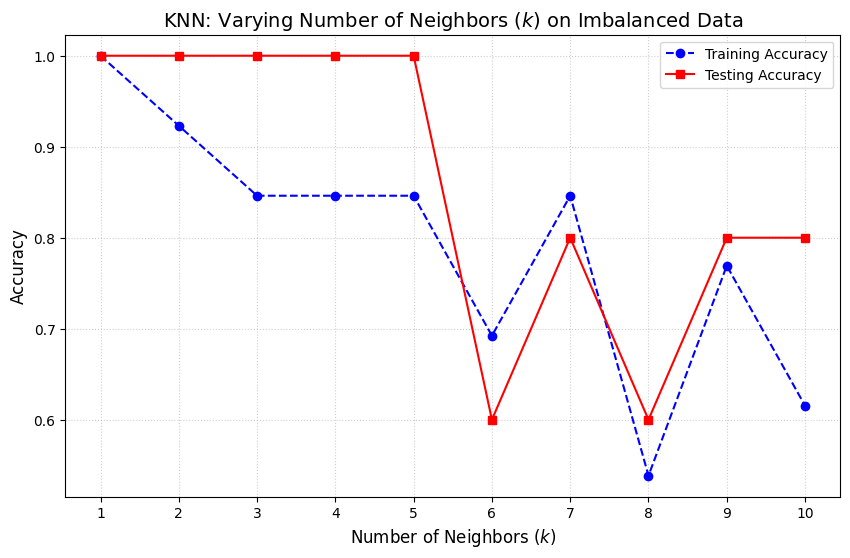

In [159]:
k_values = range(1, 11)
train_accuracies = []
test_accuracies = []
for k in k_values:
    # Train model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Calculate and store accuracies
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

# 4. Plot the results using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, marker='o', label='Training Accuracy', color='blue', linestyle='--')
plt.plot(k_values, test_accuracies, marker='s', label='Testing Accuracy', color='red')

# Adding labels and styling
plt.title('KNN: Varying Number of Neighbors ($k$) on Imbalanced Data', fontsize=14)
plt.xlabel('Number of Neighbors ($k$)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Display the graph
plt.show()

> **Conclusion:**  This analysis demonstrates how the K-Nearest Neighbors (KNN) algorithm is highly sensitive to neighborhood sizes ($k$) when trained on small, overlapping, and imbalanced datasets. For $k$ values between 1 and 5, the model successfully captures localized patterns, yielding high testing accuracy. However, as $k$ increases beyond 5, the decision boundaries become unstable, resulting in a volatile, zig-zagging accuracy curve. This behavior highlights a classic bias-variance tradeoff: smaller $k$ values risk overfitting to local noise, while larger $k$ values expand the voting radius so much that minority class structures are completely overwhelmed by the surrounding majority class noise.